# Reto 1: Humano vs Máquina - La Batalla de los Pingüinos 🐧

## Expedición Antártica Palmer - Clasificación de Especies

---

```
                                    .-.
                                   /   \
                                  |  O  |
                                  |  _  |
                                 /|     |\
                                / |     | \
    ╔═══════════════════════╗  /  |     |  \
    ║  EXPEDICIÓN PALMER    ║ /   |_____|   \
    ║  ANTÁRTIDA 2026       ║/    /     \    \
    ║                       ║    /       \
    ║  MISIÓN: Clasificar   ║   /  ADELIE \
    ║  especies de          ║  /  CHINSTRAP\
    ║  pingüinos            ║ /   GENTOO    \
    ╚═══════════════════════╝/_______________\
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                    OCÉANO ANTÁRTICO
```

---

## 📋 Contexto de la Misión

**Fecha:** Febrero 2026  
**Ubicación:** Estación Palmer, Archipiélago Palmer, Antártida  
**Equipo:** Tú, como biólogo/a de campo recién integrado/a

https://es.wikipedia.org/wiki/Base_Palmer

### La Situación

Has sido reclutado/a para una expedición científica en la **Estación Palmer**, ubicada en la Península Antártica. El equipo de investigación lleva años monitoreando tres especies de pingüinos:

```
    ADELIE                CHINSTRAP              GENTOO
    ══════                ═════════              ══════
      ▄▄                     ▄▄                    ▄▄
    ▄████▄                 ▄████▄                ▄████▄
   ██○██○██               ██○██○██              ██○██○██
    ██▄▄██                 ██━━██                ██▄▄██
     ████                   ████                  ████
    ██  ██                 ██  ██                ██  ██
    
   Ojos blancos          Línea en             Mancha blanca
   característicos       la barbilla          en la cabeza
```

### El Desafío

El sistema automático de clasificación de la estación falló, y hay **344 pingüinos** que necesitan ser clasificados antes de que termine la temporada de investigación.

La Dra. Kristen Gorman, líder del proyecto, te propone un reto:

> *"Diseña tus propias reglas de clasificación basándote en las medidas físicas de los pingüinos. Luego compararemos tu sistema con un modelo de Machine Learning. ¿Quién ganará: el humano o la máquina?"*

---

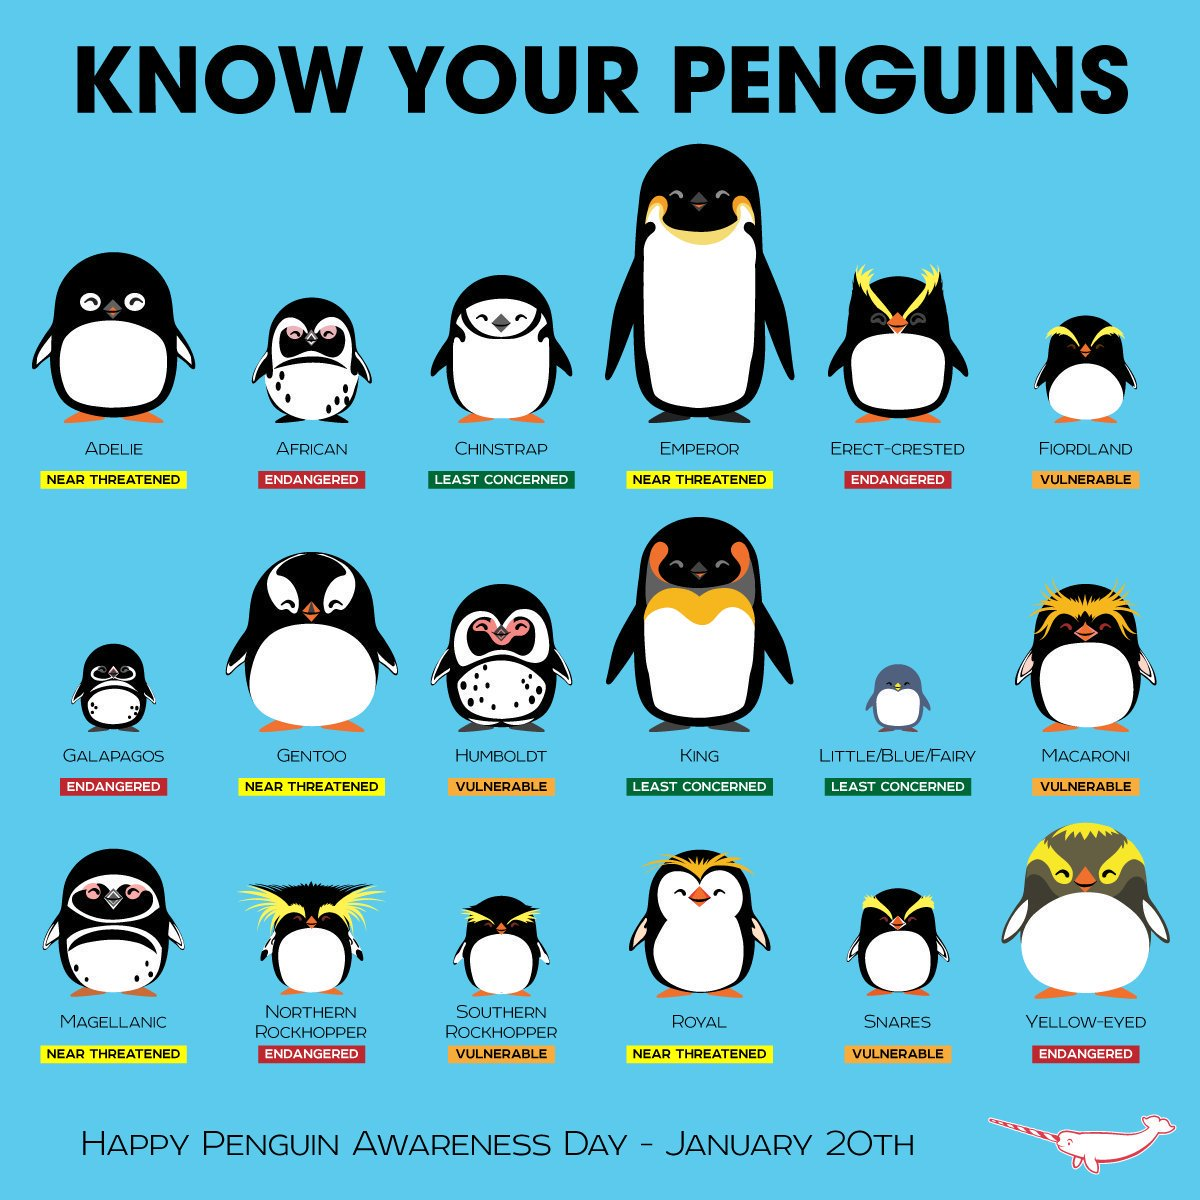

## 🎯 Objetivos del Reto

Al completar este reto, habrás:

1. ✅ Explorado un dataset real de pingüinos de la Antártida
2. ✅ Creado reglas de clasificación **manuales** (enfoque tradicional)
3. ✅ Entrenado un modelo de Machine Learning (enfoque ML)
4. ✅ Comparado ambos enfoques y reflexionado sobre las diferencias
5. ✅ Experimentado de primera mano por qué ML es tan poderoso

---

## 📊 Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Exploración y comprensión del dataset | 15 pts |
| **Parte 2** | Diseño de reglas manuales de clasificación | 25 pts |
| **Parte 3** | Implementación y evaluación del clasificador humano | 20 pts |
| **Parte 4** | Entrenamiento del modelo de Machine Learning | 20 pts |
| **Parte 5** | Batalla final y análisis comparativo | 20 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | Mejora tu clasificador humano después de ver los errores | +10 pts |

---

## 🔧 Configuración Inicial

Ejecuta esta celda para preparar tu estación de trabajo científica.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE LA ESTACIÓN PALMER - NO MODIFICAR
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

# Colores oficiales de cada especie (inspirados en sus características)
COLORES_ESPECIES = {
    'Adelie': '#FF6B6B',      # Rojo coral
    'Chinstrap': '#4ECDC4',   # Turquesa
    'Gentoo': '#45B7D1'       # Azul cielo
}

print("╔═══════════════════════════════════════════════════════════════╗")
print("║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧    ║")
print("║                                                               ║")
print("║   Bibliotecas cargadas correctamente                          ║")
print("║   Modo: HUMANO VS MÁQUINA                                     ║")
print("║                                                               ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧    ║
║                                                               ║
║   Bibliotecas cargadas correctamente                          ║
║   Modo: HUMANO VS MÁQUINA                                     ║
║                                                               ║
╚═══════════════════════════════════════════════════════════════╝


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CARGAR DATOS DE CAMPO - Dataset Palmer Penguins
# ═══════════════════════════════════════════════════════════════════════════

# Cargar el dataset de pingüinos (viene con seaborn)
df_original = sns.load_dataset('penguins')

# Eliminar filas con valores nulos para simplificar
df = df_original.dropna().reset_index(drop=True)

print("📡 Transmisión recibida desde Estación Palmer...")
print("")
print(f"   📊 Registros de pingüinos cargados: {len(df)}")
print(f"   🏝️  Islas monitoreadas: {df['island'].nunique()}")
print(f"   🐧 Especies identificadas: {df['species'].nunique()}")
print("")
print("   Distribución por especie:")
for species in df['species'].unique():
    count = (df['species'] == species).sum()
    print(f"      • {species}: {count} individuos")

print("")
print("✅ Datos listos para análisis")

📡 Transmisión recibida desde Estación Palmer...

   📊 Registros de pingüinos cargados: 333
   🏝️  Islas monitoreadas: 3
   🐧 Especies identificadas: 3

   Distribución por especie:
      • Adelie: 146 individuos
      • Chinstrap: 68 individuos
      • Gentoo: 119 individuos

✅ Datos listos para análisis


---

# PARTE 1: Exploración del Dataset (15 puntos)

## 📖 Conociendo a los Pingüinos

Antes de crear reglas de clasificación, necesitas **entender los datos**. Un buen científico siempre explora antes de actuar.

### Las Variables Disponibles

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    FICHA TÉCNICA DEL PINGÜINO                           │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│     ┌──────────┐                                                        │
│     │ ┌────┐   │◄──── bill_length_mm (largo del pico)                   │
│     │ │    │   │                                                        │
│     │ └────┘   │◄──── bill_depth_mm (profundidad/alto del pico)         │
│     │  ○  ○    │                                                        │
│     │   __     │                                                        │
│     │  ████    │                                                        │
│     │ ██████   │◄──── body_mass_g (masa corporal en gramos)             │
│     │  ████    │                                                        │
│     │ ▓▓  ▓▓   │◄──── flipper_length_mm (largo de la aleta)             │
│     └──────────┘                                                        │
│                                                                         │
│     + species (especie): Adelie, Chinstrap, Gentoo                      │
│     + island (isla): Torgersen, Biscoe, Dream                           │
│     + sex (sexo): male, female                                          │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

In [3]:
# Veamos las primeras filas del dataset
print("🔍 Primeros 10 registros del campo:")
print("="*80)
df.head(10)

🔍 Primeros 10 registros del campo:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
5,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
6,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
7,Adelie,Torgersen,41.1,17.6,182.0,3200.0,Female
8,Adelie,Torgersen,38.6,21.2,191.0,3800.0,Male
9,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male


### Ejercicio 1.1: Estadísticas Básicas (5 puntos)

Calcula las estadísticas descriptivas del dataset usando `.describe()` y responde las preguntas.

In [4]:
# TU CÓDIGO AQUÍ: Muestra las estadísticas descriptivas del dataset
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


**Responde en esta celda:**

1. ¿Cuál es el rango de masa corporal (body_mass_g) de los pingüinos? (mínimo a máximo)
   - [2700.0, 6300.0] 

2. ¿Cuál es la longitud promedio del pico (bill_length_mm)?
   - 43.992793 

3. ¿Cuál es la longitud promedio de la aleta (flipper_length_mm)?
   - 200.966967 

### Ejercicio 1.2: Estadísticas por Especie (10 puntos)

Ahora lo importante: ¿cómo se diferencian las especies? Calcula el **promedio de cada variable numérica para cada especie**.

In [5]:
# TU CÓDIGO AQUÍ: Calcula el promedio de cada variable agrupando por especie


columnas_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df.groupby(["species"]).mean(columnas_numericas)



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


**Responde en esta celda:**

Basándote en los promedios por especie:

1. ¿Qué especie tiene el pico más largo en promedio?
   - Chinstrap 

2. ¿Qué especie tiene las aletas más largas?
   - La Gentoo

3. ¿Qué especie es la más pesada?
   - La Gentoo

4. ¿Qué especie tiene el pico más profundo (bill_depth más alto)?
   - La Chinstrap

### Visualización de Apoyo

Ejecuta la siguiente celda para ver gráficamente las diferencias entre especies. **Esto te ayudará a diseñar tus reglas.**

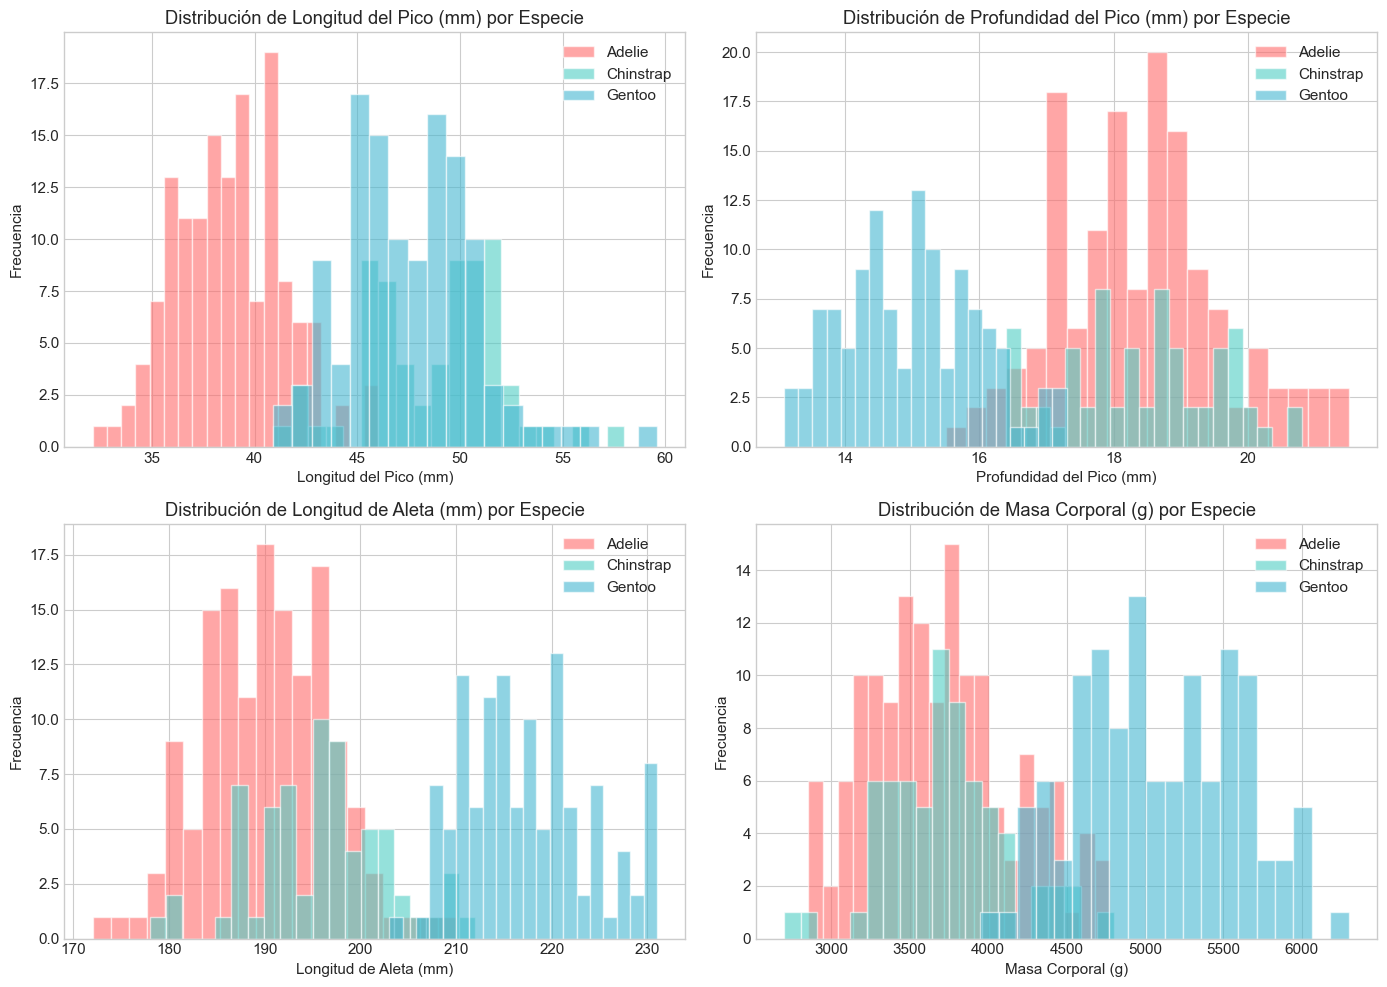


💡 OBSERVA: ¿Qué variables separan mejor las especies?
   Busca variables donde los histogramas NO se solapan mucho.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Diferencias entre especies
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
titulos = ['Longitud del Pico (mm)', 'Profundidad del Pico (mm)', 
           'Longitud de Aleta (mm)', 'Masa Corporal (g)']

for ax, var, titulo in zip(axes.flat, variables, titulos):
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[var], alpha=0.6, label=species, 
                color=COLORES_ESPECIES[species], bins=20, edgecolor='white')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.set_title(f'Distribución de {titulo} por Especie')

plt.tight_layout()
plt.savefig('pinguinos_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 OBSERVA: ¿Qué variables separan mejor las especies?")
print("   Busca variables donde los histogramas NO se solapan mucho.")

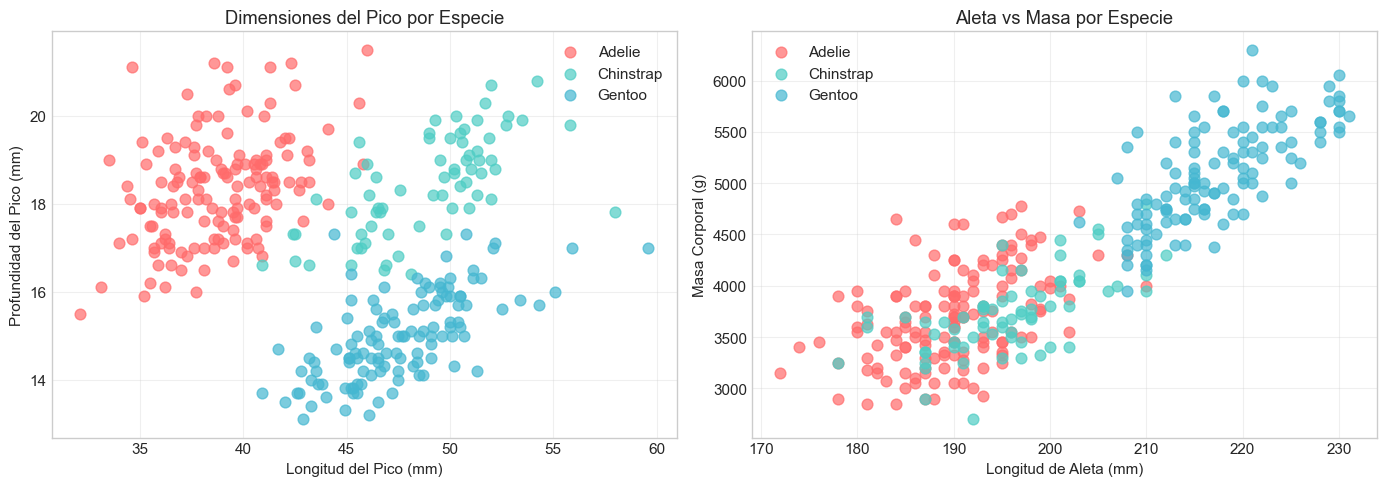


💡 PISTA IMPORTANTE:
   Observa la gráfica de la derecha (Aleta vs Masa).
   ¿Puedes ver que una especie está claramente separada de las otras dos?
   ¿Podrías dibujar una línea horizontal o vertical que la separe?


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Scatter plot para encontrar fronteras de decisión
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Pico (longitud vs profundidad)
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[0].scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
                   c=COLORES_ESPECIES[species], label=species, alpha=0.7, s=60)
axes[0].set_xlabel('Longitud del Pico (mm)')
axes[0].set_ylabel('Profundidad del Pico (mm)')
axes[0].set_title('Dimensiones del Pico por Especie')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Aleta vs Masa
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[1].scatter(subset['flipper_length_mm'], subset['body_mass_g'],
                   c=COLORES_ESPECIES[species], label=species, alpha=0.7, s=60)
axes[1].set_xlabel('Longitud de Aleta (mm)')
axes[1].set_ylabel('Masa Corporal (g)')
axes[1].set_title('Aleta vs Masa por Especie')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pinguinos_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 PISTA IMPORTANTE:")
print("   Observa la gráfica de la derecha (Aleta vs Masa).")
print("   ¿Puedes ver que una especie está claramente separada de las otras dos?")
print("   ¿Podrías dibujar una línea horizontal o vertical que la separe?")

---

# PARTE 2: Diseño de Reglas de Clasificación (25 puntos)

## 🧠 Tu Turno: Crea las Reglas

Ahora que exploraste los datos, es momento de **pensar como un experto** y diseñar reglas para clasificar pingüinos.

### Ejemplo de Regla

```python
# Ejemplo (puede no ser óptimo):
if flipper_length_mm > 210:
    return "Gentoo"
elif bill_length_mm > 45:
    return "Chinstrap"
else:
    return "Adelie"
```

### Tu Tarea

1. Observa las gráficas anteriores cuidadosamente
2. Identifica **umbrales** (valores límite) que separen las especies
3. Diseña tu conjunto de reglas
4. Documenta tu razonamiento

### Ejercicio 2.1: Documenta tu Estrategia (10 puntos)

Antes de codificar, explica tu estrategia:

**Responde aquí:**

1. ¿Qué variable(s) usarás para separar primero una especie de las otras?
   - Longitud de aleta

2. ¿Qué umbral(es) numérico(s) planeas usar? (ej: "si aleta > 210")
   - aleta  > 207

3. ¿Cuál especie crees que será más fácil de identificar? ¿Por qué?
   - La Gentoo, ya que se observa que son los pinguinos más grandes, y el umbral planteado en la pregunta 2 los separa de una manera satisfactoria

4. ¿Cuál especie crees que será más difícil? ¿Por qué?
   - Chinstrap, debido a que es el pinguino "mediano", y sus espécimenes grandes se pueden confundir con los Gentoos pequeños, y sus espécimenes pequeñños se pueden confundir con los Adelies grandes

### Ejercicio 2.2: Implementa tu Clasificador Humano (15 puntos)

Completa la función `clasificador_humano()` con TUS propias reglas.

**Reglas del juego:**
- Solo puedes usar las 4 variables numéricas: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
- NO puedes usar la isla (sería trampa, ya que ciertas especies solo viven en ciertas islas)
- Puedes usar tantas reglas if/elif/else como quieras
- La función debe retornar: `'Adelie'`, `'Chinstrap'`, o `'Gentoo'`

In [8]:
def clasificador_humano(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g):
    """
    Clasifica un pingüino basándose en reglas diseñadas por un humano.
    
    Parámetros:
    -----------
    bill_length_mm : float
        Longitud del pico en milímetros
    bill_depth_mm : float
        Profundidad del pico en milímetros
    flipper_length_mm : float
        Longitud de la aleta en milímetros
    body_mass_g : float
        Masa corporal en gramos
        
    Retorna:
    --------
    str : 'Adelie', 'Chinstrap', o 'Gentoo'
    """
    
    # Ejemplo (reemplaza con tus propias reglas):
    if flipper_length_mm > 207:
        return "Gentoo"
    elif bill_length_mm > 45:
        return "Chinstrap"
    else:
        return "Adelie"
    


In [9]:
# Prueba rápida de tu clasificador con algunos ejemplos
print("🧪 Prueba de tu clasificador humano:")
print("="*60)

# Casos de prueba (valores típicos de cada especie)
casos_prueba = [
    # [bill_length, bill_depth, flipper_length, body_mass, especie_real]
    [39.1, 18.7, 181, 3750, "Adelie"],
    [46.5, 17.9, 192, 3500, "Chinstrap"],
    [46.1, 13.2, 211, 4500, "Gentoo"],
]

print(f"{'Pico L':>8} {'Pico D':>8} {'Aleta':>8} {'Masa':>8} │ {'Real':>12} {'Tu Pred':>12} {'¿Correcto?':>12}")
print("-" * 80)

for caso in casos_prueba:
    pred = clasificador_humano(caso[0], caso[1], caso[2], caso[3])
    real = caso[4]
    correcto = "✅" if pred == real else "❌"
    print(f"{caso[0]:>8.1f} {caso[1]:>8.1f} {caso[2]:>8} {caso[3]:>8} │ {real:>12} {str(pred):>12} {correcto:>12}")

🧪 Prueba de tu clasificador humano:
  Pico L   Pico D    Aleta     Masa │         Real      Tu Pred   ¿Correcto?
--------------------------------------------------------------------------------
    39.1     18.7      181     3750 │       Adelie       Adelie            ✅
    46.5     17.9      192     3500 │    Chinstrap    Chinstrap            ✅
    46.1     13.2      211     4500 │       Gentoo       Gentoo            ✅


---

# PARTE 3: Evaluación del Clasificador Humano (20 puntos)

## 📊 ¿Qué tan bueno es tu clasificador?

Ahora evaluaremos tu clasificador con **todos los datos de prueba**.

### Ejercicio 3.1: Prepara los Datos (5 puntos)

Divide el dataset en entrenamiento (80%) y prueba (20%).

In [10]:
# Definir features (X) y label (y)
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Verifica tu división:
print(f"📊 División de datos:")
print(f"   Entrenamiento: {len(X_train)} pingüinos")
print(f"   Prueba: {len(X_test)} pingüinos")

📊 División de datos:
   Entrenamiento: 266 pingüinos
   Prueba: 67 pingüinos


### Ejercicio 3.2: Evalúa tu Clasificador (15 puntos)

Aplica tu clasificador a todos los datos de prueba y calcula el accuracy.

In [11]:
# Aplicar tu clasificador a todos los datos de prueba
predicciones_humano = []

for idx, row in X_test.iterrows():
    pred = clasificador_humano(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano.append(pred)



accuracy_humano = accuracy_score(y_test, predicciones_humano)

print("╔═══════════════════════════════════════════════════════════════╗")
print("║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧠           ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_humano:.2%}                                            ║")
print(f"║   Aciertos: {int(accuracy_humano * len(y_test))} de {len(y_test)} pingüinos                                ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧠           ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 94.03%                                            ║
║   Aciertos: 63 de 67 pingüinos                                ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Clasificador Humano:


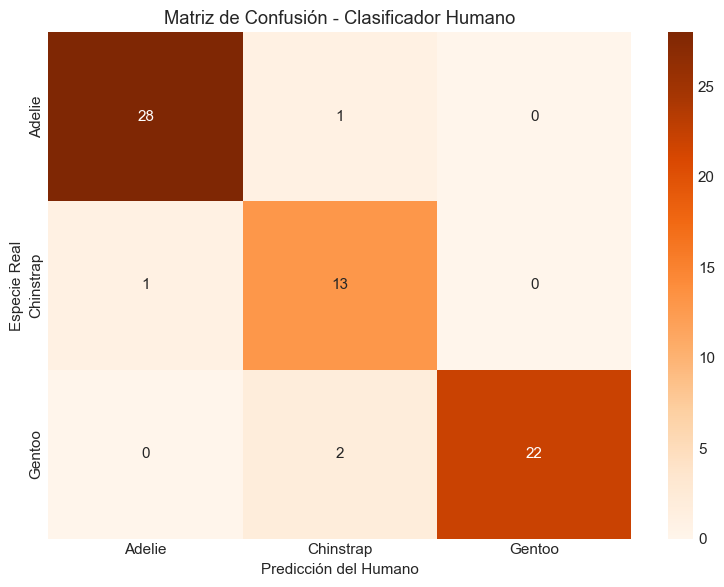


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.81      0.93      0.87        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.94        67
   macro avg       0.93      0.94      0.93        67
weighted avg       0.95      0.94      0.94        67



In [12]:
# Matriz de confusión de tu clasificador
print("\n📋 Matriz de Confusión - Clasificador Humano:")
print("="*50)

cm_humano = confusion_matrix(y_test, predicciones_humano, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Humano')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Clasificador Humano')
plt.tight_layout()
plt.savefig('confusion_humano.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_humano))

**Reflexiona sobre tus resultados:**

1. ¿Qué especie clasificaste mejor?
   - La especie Adelie muestra un mejor desempeño según las métricas recall, f1, y support. Esto se explica porque fueron más individuos Adelie, y solo clasificó  uno como Chinstrap, lo que aumenta la proporción de las clasificaciones correctas.
   - Sin embargo, también vale la pena mencionar que los Gentoo tuvieron un accuracy del 100%, solo se clasificaron como Gentoo a los Gentoo 

2. ¿Qué especie te dio más problemas? ¿Por qué crees que pasó?
   - En general, los Chinstrap muestran métricas de desempeño más bajas, se puede explicar porque son los pingüinos que se encontraban "en medio" de las dos especies (los medianos)

3. ¿Cuántos pingüinos clasificaste incorrectamente?
   - Cuatro pingüinos

---

# PARTE 4: El Clasificador de Machine Learning (20 puntos)

## 🤖 Ahora le toca a la Máquina

Entrenaremos un **Árbol de Decisión** (el mismo algoritmo que vimos en clase) y veremos cómo le va.

### Ejercicio 4.1: Entrena el Modelo (10 puntos)

Crea y entrena un `DecisionTreeClassifier`.

In [24]:
# TU CÓDIGO AQUÍ: Crea y entrena un DecisionTreeClassifier

# 1. Crea el modelo (usa random_state=42 para reproducibilidad)
modelo_ml = DecisionTreeClassifier(random_state=42,max_depth=4)


# 2. Entrena el modelo con los datos de entrenamiento
modelo_ml.fit(X,y)


print("✅ Modelo de Machine Learning entrenado!")
print(f"   Profundidad del árbol: {modelo_ml.get_depth()}")
print(f"   Número de hojas: {modelo_ml.get_n_leaves()}")

✅ Modelo de Machine Learning entrenado!
   Profundidad del árbol: 4
   Número de hojas: 10


### Ejercicio 4.2: Evalúa el Modelo ML (10 puntos)

Haz predicciones y calcula el accuracy.

In [25]:
# TU CÓDIGO AQUÍ: Haz predicciones con el modelo ML

# 1. Predice las especies para X_test
predicciones_ml = modelo_ml.predict(X_test)


# 2. Calcula el accuracy
accuracy_ml = accuracy_score(y_test,predicciones_ml)


print("╔═══════════════════════════════════════════════════════════════╗")
print("║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                 ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_ml:.2%}                                           ║")
print(f"║   Aciertos: {int(accuracy_ml * len(y_test))} de {len(y_test)} pingüinos                                ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                 ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 98.51%                                           ║
║   Aciertos: 66 de 67 pingüinos                                ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Modelo ML:


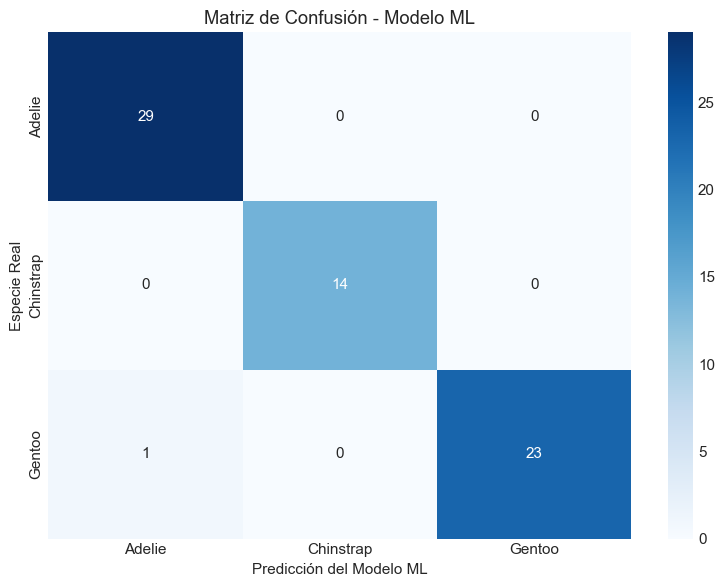


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      0.96      0.98        24

    accuracy                           0.99        67
   macro avg       0.99      0.99      0.99        67
weighted avg       0.99      0.99      0.99        67



In [26]:
# Matriz de confusión del modelo ML
print("\n📋 Matriz de Confusión - Modelo ML:")
print("="*50)

cm_ml = confusion_matrix(y_test, predicciones_ml, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Modelo ML')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Modelo ML')
plt.tight_layout()
plt.savefig('confusion_ml.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_ml))

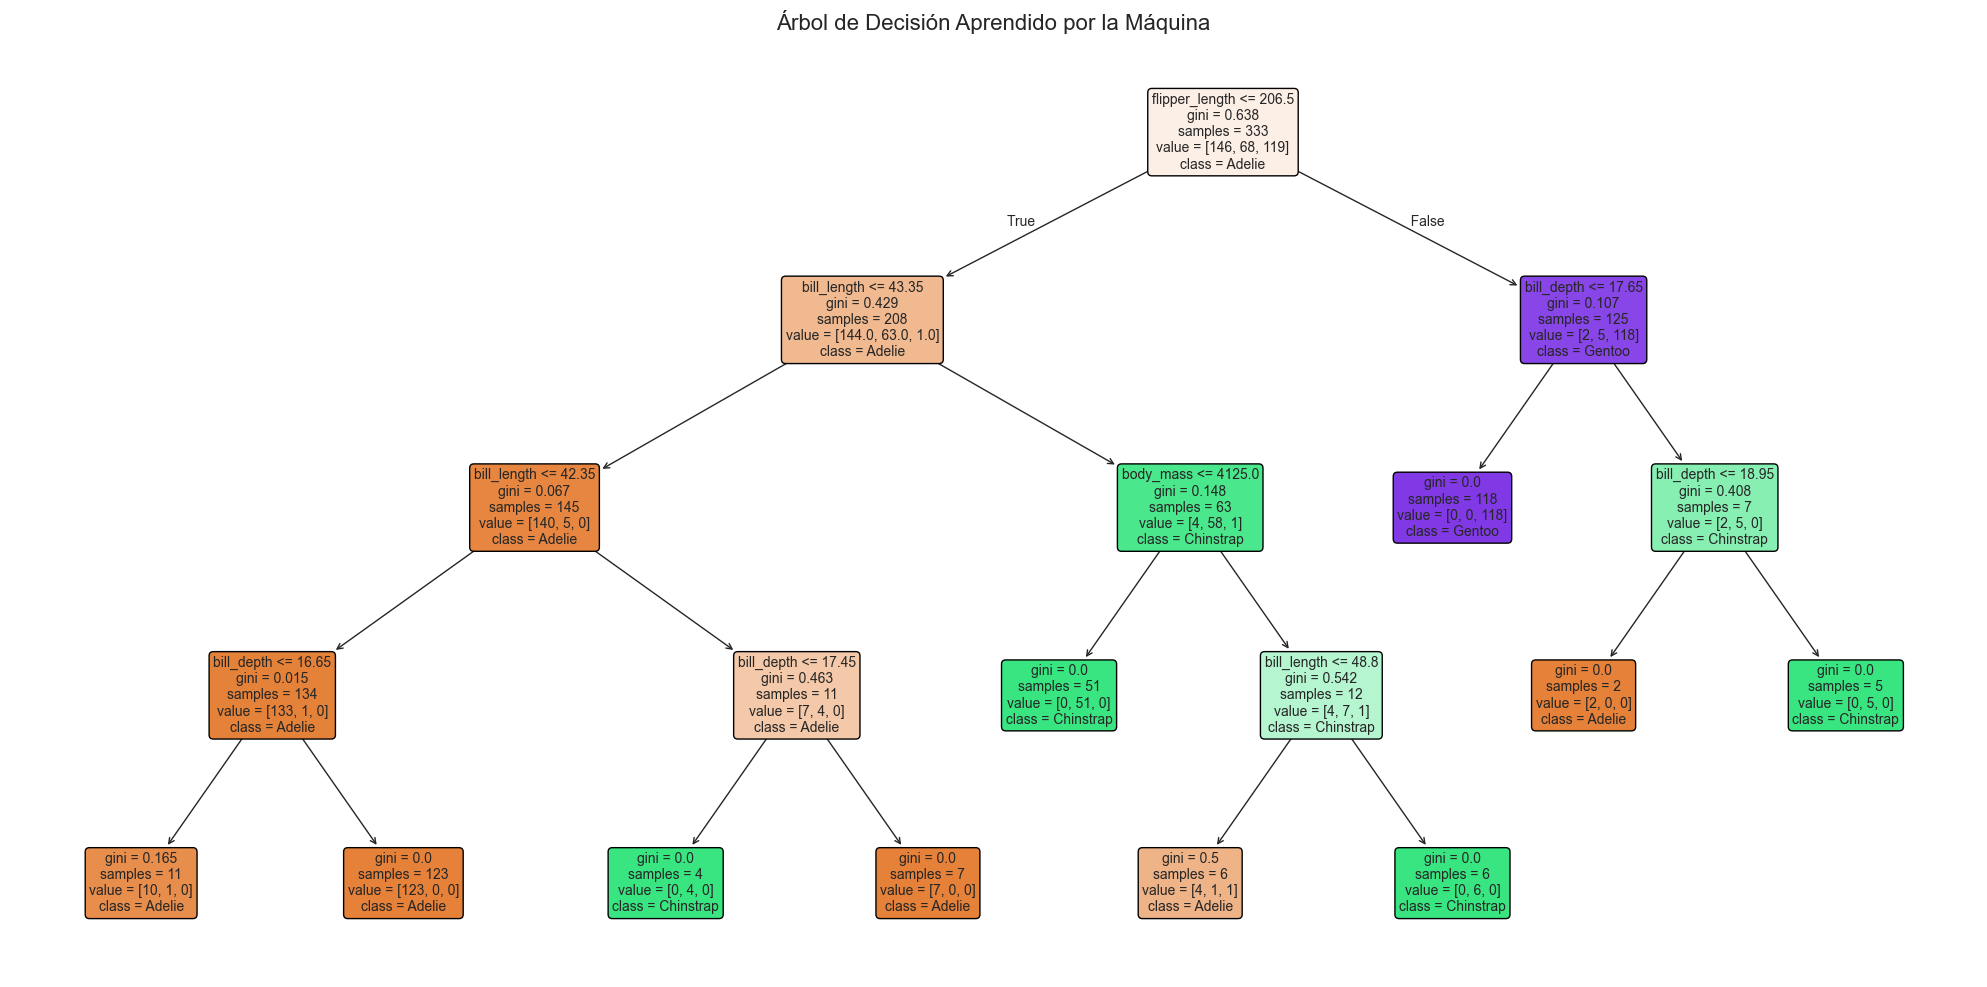


💡 Observa: Estas son las reglas que la MÁQUINA descubrió automáticamente.
   ¿Son similares a las tuyas? ¿Usó las mismas variables?


In [27]:
# Visualiza las reglas que aprendió la máquina
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_ml,
    feature_names=['bill_length', 'bill_depth', 'flipper_length', 'body_mass'],
    class_names=['Adelie', 'Chinstrap', 'Gentoo'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión Aprendido por la Máquina', fontsize=16)
plt.tight_layout()
plt.savefig('arbol_pinguinos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Observa: Estas son las reglas que la MÁQUINA descubrió automáticamente.")
print("   ¿Son similares a las tuyas? ¿Usó las mismas variables?")

---

# PARTE 5: La Batalla Final (20 puntos)

## ⚔️ Humano vs Máquina: ¿Quién Gana?

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN FINAL
# ═══════════════════════════════════════════════════════════════════════════

print("")
print("╔═══════════════════════════════════════════════════════════════════════════╗")
print("║                                                                           ║")
print("║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                       ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")
print("║                                                                           ║")
print(f"║   🧠 CLASIFICADOR HUMANO:     {accuracy_humano:.2%} accuracy                             ║")
print(f"║      Aciertos: {int(accuracy_humano * len(y_test)):2d}/{len(y_test)} pingüinos                                            ║")
print("║                                                                           ║")
print(f"║   🤖 CLASIFICADOR ML:         {accuracy_ml:.2%} accuracy                            ║")
print(f"║      Aciertos: {int(accuracy_ml * len(y_test)):2d}/{len(y_test)} pingüinos                                            ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")

diferencia = accuracy_ml - accuracy_humano

if diferencia > 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: LA MÁQUINA 🏆                            ║")
    print(f"║                     Ventaja: +{diferencia:.2%}                                       ║")
    print("║                                                                           ║")
elif diferencia < 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: EL HUMANO 🏆                              ║")
    print(f"║                     Ventaja: +{-diferencia:.2%}                                   ║")
    print("║                                                                           ║")
else:
    print("║                                                                           ║")
    print("║                        🤝 EMPATE TÉCNICO 🤝                               ║")
    print("║                                                                           ║")

print("╚═══════════════════════════════════════════════════════════════════════════╝")


╔═══════════════════════════════════════════════════════════════════════════╗
║                                                                           ║
║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                       ║
║                                                                           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║   🧠 CLASIFICADOR HUMANO:     94.03% accuracy                             ║
║      Aciertos: 63/67 pingüinos                                            ║
║                                                                           ║
║   🤖 CLASIFICADOR ML:         98.51% accuracy                            ║
║      Aciertos: 66/67 pingüinos                                            ║
║                                                                           ║
╠══════════════════════════════════════════════════════════════════

C:\Users\andy1\AppData\Local\Temp\ipykernel_18160\3931004592.py:32: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\andy1\AppData\Local\Temp\ipykernel_18160\3931004592.py:33: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
c:\Users\andy1\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


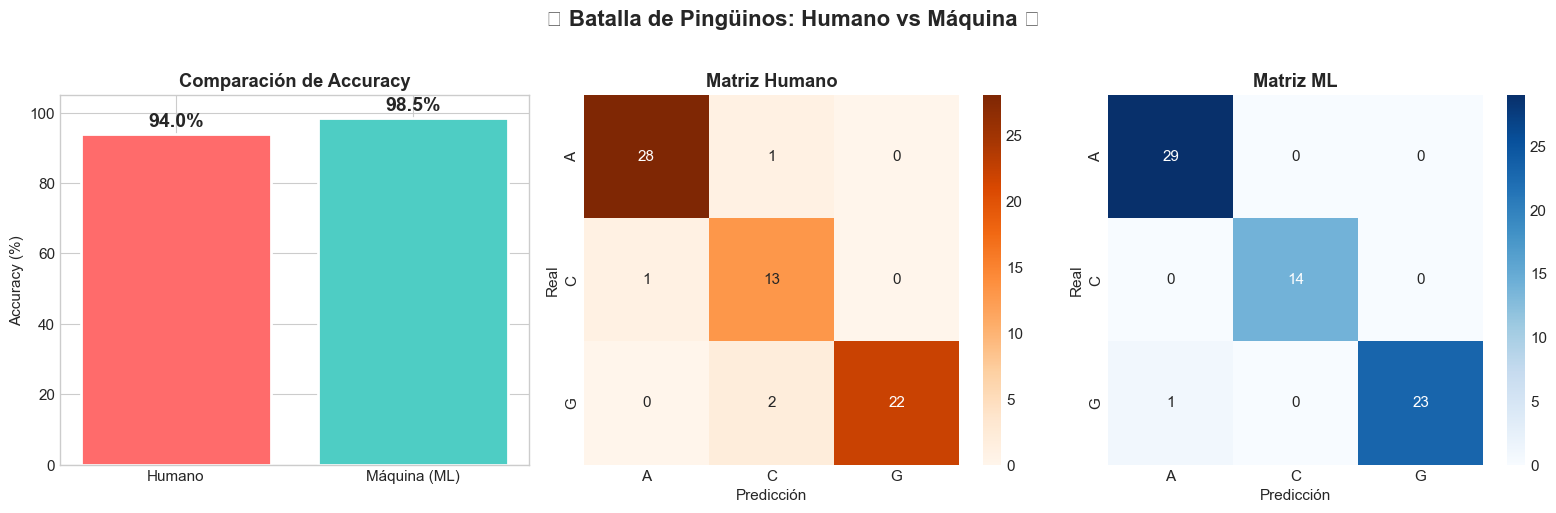

In [29]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Barras de accuracy
clasificadores = ['Humano', 'Máquina (ML)']
accuracies = [accuracy_humano * 100, accuracy_ml * 100]
colores_barras = ['#FF6B6B', '#4ECDC4']

bars = axes[0].bar(clasificadores, accuracies, color=colores_barras, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Comparación de Accuracy', fontweight='bold')
axes[0].set_ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Gráfica 2: Matrices de confusión lado a lado (Humano)
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[1].set_title('Matriz Humano', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Gráfica 3: Matriz ML
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[2].set_title('Matriz ML', fontweight='bold')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Real')

plt.suptitle('🐧 Batalla de Pingüinos: Humano vs Máquina 🐧', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
plt.show()

### Ejercicio 5.1: Análisis de Errores (10 puntos)

Identifica los casos donde cada clasificador falló.

In [30]:
# Crear DataFrame con resultados
resultados = X_test.copy()
resultados['especie_real'] = y_test.values
resultados['pred_humano'] = predicciones_humano
resultados['pred_ml'] = predicciones_ml
resultados['error_humano'] = resultados['especie_real'] != resultados['pred_humano']
resultados['error_ml'] = resultados['especie_real'] != resultados['pred_ml']

# Mostrar errores del humano
errores_humano = resultados[resultados['error_humano']]
print(f"❌ Errores del clasificador HUMANO ({len(errores_humano)} casos):")
print("="*80)
if len(errores_humano) > 0:
    print(errores_humano[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 
                          'body_mass_g', 'especie_real', 'pred_humano']].to_string())
else:
    print("¡Ningún error! 🎉")

❌ Errores del clasificador HUMANO (4 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real pred_humano
168            43.2           16.6              187.0       2900.0    Chinstrap      Adelie
245            45.1           14.5              207.0       5050.0       Gentoo   Chinstrap
14             46.0           21.5              194.0       4200.0       Adelie   Chinstrap
310            48.4           14.4              203.0       4625.0       Gentoo   Chinstrap


In [31]:
# Mostrar errores de la máquina
errores_ml = resultados[resultados['error_ml']]
print(f"\n❌ Errores del clasificador ML ({len(errores_ml)} casos):")
print("="*80)
if len(errores_ml) > 0:
    print(errores_ml[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 
                      'body_mass_g', 'especie_real', 'pred_ml']].to_string())
else:
    print("¡Ningún error! 🎉")


❌ Errores del clasificador ML (1 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real pred_ml
310            48.4           14.4              203.0       4625.0       Gentoo  Adelie


### Ejercicio 5.2: Reflexión Final (10 puntos)

**Responde las siguientes preguntas basándote en tus resultados:**

1. **¿Quién ganó la batalla y por cuánto?**
   - La máquina, por 3 errores

2. **¿Qué errores cometiste que la máquina no cometió?** (o viceversa)
   - Clasifiqué a 3 pinguinos como Chinstrap, y un Chinstrap como Adelie

3. **¿Las reglas del árbol de decisión se parecen a las tuyas?** ¿Usó las mismas variables?
   - No se parecen mucho, yo usé las variables: flipper lenght y bill lenght, y la máquina utilizó las 4 variables, utilizando a bill lenght y bill depth como los primeros nodos.

4. **¿Cuál es la principal ventaja de usar Machine Learning sobre reglas manuales?**
   - Las reglas son más acertadas con el ML, ya que puede analizar al conjunto de datos de una manera más eficiente y eficaz que el ser humano a simple vista

5. **¿Qué harías diferente si pudieras volver a diseñar tus reglas?**
   - Haría más reglas, y utilizaría operadores lógicos con ellas

---

# BONUS: Mejora tu Clasificador (+10 puntos)

## 🔄 Segunda Oportunidad

Ahora que viste dónde fallaste y qué reglas encontró la máquina, ¿puedes mejorar tu clasificador?

**Requisitos para el bonus:**
1. Crea una versión mejorada de `clasificador_humano()`
2. Explica qué cambios hiciste y por qué
3. Demuestra que el accuracy mejoró

In [32]:
def clasificador_humano_v2(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g):
    """
    Versión mejorada del clasificador humano.

    Parámetros:
    -----------
    bill_length_mm : float
        Longitud del pico en milímetros
    bill_depth_mm : float
        Profundidad del pico en milímetros
    flipper_length_mm : float
        Longitud de la aleta en milímetros
    body_mass_g : float
        Masa corporal en gramos
        
    Retorna:
    --------
    str : 'Adelie', 'Chinstrap', o 'Gentoo'
    
    DOCUMENTA TUS CAMBIOS:
    En la grafica scatterplot longitud de pico, se ve que el 44 separa a la adelie y a la chinstrap, los adelie tienen picos más cortos.
    Para distinguir a estas especies de la gentoo, se identificó que los gentoo tienen sus aletas de longitud mayor a 207.
    Sin embargo, también existen pingüinos Chinstrap grandes, con una longitud de aleta superior. En vista de esto, se pueden distinguir 
    de los Gentoo con la profundidad de su pico,  los Chinstrap tienen un pico profundo, superior a los 17.5 mm en su mayoría. Esto se observa 
    en los histogramas de distribución de profundidad de pico. 

    """
    
    # Ejemplo (reemplaza con tus propias reglas):
    if flipper_length_mm < 206.5:
        if bill_length_mm < 43.4:
            return "Adelie"
        else:
            return "Chinstrap"
    else:
        if bill_depth_mm < 17.6:
            return "Gentoo"
        else:
            return "Chinstrap"
    
    

In [33]:
# Evalúa tu clasificador mejorado
predicciones_humano_v2 = []

for idx, row in X_test.iterrows():
    pred = clasificador_humano_v2(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano_v2.append(pred)

accuracy_humano_v2 = accuracy_score(y_test, predicciones_humano_v2)

print("╔═══════════════════════════════════════════════════════════════╗")
print("║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈             ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Versión 1: {accuracy_humano:.2%}                                         ║")
print(f"║   Versión 2: {accuracy_humano_v2:.2%}                                         ║")
print(f"║   Mejora:    {(accuracy_humano_v2 - accuracy_humano):.2%}                                         ║")
print("╚═══════════════════════════════════════════════════════════════╝")

if accuracy_humano_v2 > accuracy_humano:
    print("\n🎉 ¡Excelente! Tu clasificador mejoró.")
else:
    print("\n🤔 Hmm, no hubo mejora. ¿Puedes intentar otros cambios?")

╔═══════════════════════════════════════════════════════════════╗
║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈             ║
╠═══════════════════════════════════════════════════════════════╣
║   Versión 1: 94.03%                                         ║
║   Versión 2: 95.52%                                         ║
║   Mejora:    1.49%                                         ║
╚═══════════════════════════════════════════════════════════════╝

🎉 ¡Excelente! Tu clasificador mejoró.


**Explica qué cambios hiciste y por qué:**

En la grafica scatterplot longitud de pico, se ve que el 44 separa a la adelie y a la chinstrap, los adelie tienen picos más cortos. Para distinguir a estas especoes de la gentoo, se identificó que los gentoo tienen sus aletas de longitud mayor a 207.

Sin embargo, también existen pingüinos Chinstrap grandes, con una longitud de aleta superior. En vista de esto, se pueden distinguir de los Gentoo con la profundidad de su pico, ya que los Chinstrap tienen un pico bastante profundo, superior a los 17.5 mm en su mayoría. Esto se observa en los histogramas de distribución de profundidad de pico 




---

# 📝 Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Estadísticas básicas y por especie calculadas
- [ ] **Parte 2:** Estrategia documentada y función `clasificador_humano()` implementada
- [ ] **Parte 3:** Datos divididos y accuracy del clasificador humano calculado
- [ ] **Parte 4:** Modelo ML entrenado y evaluado
- [ ] **Parte 5:** Análisis comparativo y reflexión final completados
- [ ] **Bonus (opcional):** Clasificador mejorado con explicación

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Respuestas reflexivas y bien argumentadas | 30 |
| Exploración correcta de datos | 15 |
| Clasificador humano creativo y razonado | 15 |
| Presentación y claridad | 10 |
| **Total** | **100** |

---

## 🎓 Lección Aprendida

Este reto demuestra la diferencia fundamental entre:

**Programación Tradicional:**
- TÚ diseñas las reglas
- Requiere conocimiento experto del dominio
- Difícil capturar patrones complejos
- Las reglas pueden ser subjetivas

**Machine Learning:**
- La MÁQUINA descubre las reglas
- Aprende de los datos
- Puede encontrar patrones que los humanos no ven
- Objetiva y reproducible

```
     HUMANO                              MÁQUINA
    ════════                            ═════════
                                        
   "Creo que si                      datos ──► algoritmo ──► reglas
    el pico es                       
    largo..."                        "Encontré que flipper_length
                                      ≤ 206.5 separa Gentoo con
   Basado en                          98.3% de confianza"
   intuición                         
                                      Basado en DATOS
```

**¡Bienvenido/a al mundo del Machine Learning!** 🚀

---

*Reto 1 - Humano vs Máquina | Modelado Predictivo 2026*